# 01 - Exploratory Data Analysis and Drift Evidence

**Project:** Drift-Robust Gas Classification Using Machine Learning (24DS601, M.Tech Data Science, Amrita)

**Goal of this notebook:** *look* at the data before modelling. We want to answer five questions:

1. What does the data look like (size, classes, quality)?
2. Which gases appear in which batch? (class balance)
3. Can we **see** sensor drift? (same gas, different months)
4. How are the 128 features related to each other? (feature analysis)
5. Do the features secretly contain **time information**? (leakage check)

> **Beginner note.** *Sensor drift* means the same gas gives slightly different sensor readings as months go by.
> The 10 *batches* are chronological, so batch 1 is the oldest data (2008) and batch 10 the newest (2011).
> Everything here is **exploration only** - nothing is tuned, and no model from this notebook is used for results.

In [1]:
import os, sys, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")
warnings.filterwarnings("ignore")
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, balanced_accuracy_score

from src.data import load_all, feature_names, GAS_NAMES, FEATURE_TYPES, N_SENSORS, FEATURES_PER_SENSOR

FIG = ROOT / "results" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
RES = ROOT / "results"

# ---- plotting style (light surface, recessive grid, thin marks) ----
INK, INK2, SURFACE, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e3e2dd"
GAS_COLORS = {1: "#2a78d6", 2: "#eb6834", 3: "#1baf7a", 4: "#eda100", 5: "#e87ba4", 6: "#008300"}
GAS_MARKERS = {1: "o", 2: "s", 3: "^", 4: "D", 5: "v", 6: "P"}
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#eef3fb", "#2a78d6", "#123c75"])
DIV = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f1f0ec", "#eb6834"])
BATCH_CMAP = plt.get_cmap("viridis")
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.titlecolor": INK, "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
})

X, y, batch = load_all()
names = feature_names()
df = pd.DataFrame(X, columns=names)
print("X:", X.shape, "| y:", y.shape, "| batch:", batch.shape)

X: (13910, 128) | y: (13910,) | batch: (13910,)


## 1. Data quality check

Before anything else we check for missing values, duplicate rows and constant (useless) features.

In [2]:
quality = pd.Series({
    "samples": X.shape[0],
    "features": X.shape[1],
    "missing values (NaN)": int(np.isnan(X).sum()),
    "duplicate rows": int(df.duplicated().sum()),
    "constant features": int((X.std(axis=0) == 0).sum()),
    "gas classes": len(np.unique(y)),
    "batches": len(np.unique(batch)),
    "min value": float(X.min()),
    "max value": float(X.max()),
})
quality

samples                  13910.0000
features                   128.0000
missing values (NaN)         0.0000
duplicate rows               0.0000
constant features            0.0000
gas classes                  6.0000
batches                     10.0000
min value               -23660.6348
max value               670687.3477
dtype: float64

**Feature scales.** Each sensor has 8 features. Some are huge (e.g. 15,000) and some tiny (e.g. 0.4).
Models such as kNN, SVM and PCA measure *distances*, so a feature with big numbers would dominate.
That is why **scaling is mandatory**. The plot shows how different the spread (standard deviation) is,
grouped by feature type.

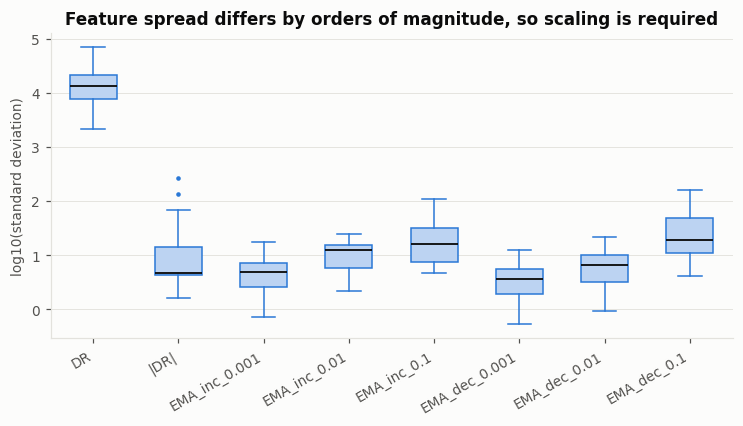

In [3]:
std = pd.DataFrame(X.std(axis=0).reshape(N_SENSORS, FEATURES_PER_SENSOR), columns=FEATURE_TYPES)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.boxplot([np.log10(std[c]) for c in FEATURE_TYPES], labels=FEATURE_TYPES, patch_artist=True, widths=0.55,
           boxprops=dict(facecolor="#bcd3f2", edgecolor="#2a78d6", linewidth=1),
           medianprops=dict(color=INK, linewidth=1.2), whiskerprops=dict(color="#2a78d6"), capprops=dict(color="#2a78d6"),
           flierprops=dict(marker="o", markersize=3, markerfacecolor="#2a78d6", markeredgecolor="none"))
ax.set_ylabel("log10(standard deviation)")
ax.set_title("Feature spread differs by orders of magnitude, so scaling is required")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.grid(axis="x", visible=False)
fig.savefig(FIG / "01_feature_scales.png"); plt.show()

## 2. Class balance per batch

Rows are the six gases, columns are the batches. Numbers are sample counts.
If a gas is missing from a batch the model can never learn (or be tested on) it there.

col_0,1,2,3,4,5,6,7,8,9,10
1 Ethanol,90,164,365,64,28,514,649,30,61,600
2 Ethylene,98,334,490,43,40,574,662,30,55,600
3 Ammonia,83,100,216,12,20,110,360,40,100,600
4 Acetaldehyde,30,109,240,30,46,29,744,33,75,600
5 Acetone,70,532,275,12,63,606,630,143,78,600
6 Toluene,74,5,0,0,0,467,568,18,101,600
Total,445,1244,1586,161,197,2300,3613,294,470,3600


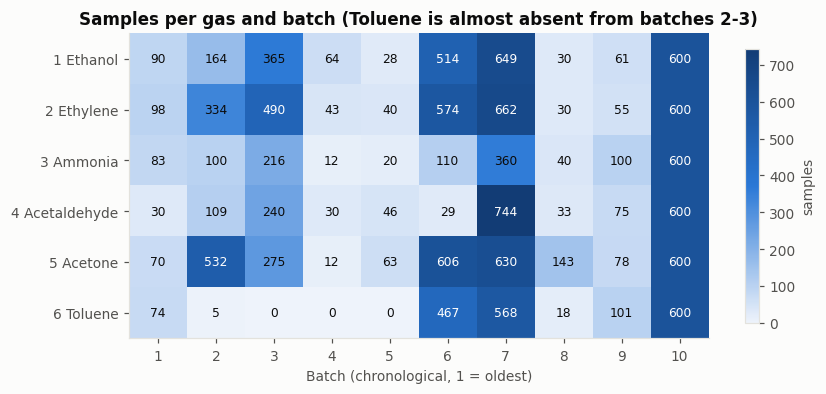

In [4]:
gas_labels = [f"{g} {GAS_NAMES[g]}" for g in range(1, 7)]
counts = pd.crosstab(y, batch); counts.index = gas_labels
counts.loc["Total"] = counts.sum()
counts.to_csv(RES / "01_class_counts.csv")
display(counts)

c = counts.drop(index="Total")
fig, ax = plt.subplots(figsize=(8.5, 3.6))
im = ax.imshow(c.values, cmap=SEQ, aspect="auto")
ax.set_xticks(range(10)); ax.set_xticklabels(range(1, 11)); ax.set_yticks(range(6)); ax.set_yticklabels(c.index)
ax.set_xlabel("Batch (chronological, 1 = oldest)"); ax.grid(False)
for i in range(c.shape[0]):
    for j in range(c.shape[1]):
        v = c.values[i, j]; ax.text(j, i, v, ha="center", va="center", fontsize=8, color="white" if v > c.values.max() * 0.55 else INK)
ax.set_title("Samples per gas and batch (Toluene is almost absent from batches 2-3)")
fig.colorbar(im, ax=ax, label="samples", shrink=0.9)
fig.savefig(FIG / "02_class_counts.png"); plt.show()

## 3. Can we see drift? Same gas, different batches

Different batches contain different gases and concentrations, so comparing raw batch averages would be unfair.
To isolate drift we look at **one gas only - Ethanol (class 1)**, which appears in every batch.
For each sensor we take the *median* steady-state response (feature `DR`) in each batch and divide by its value in batch 1.
Values are shown on a log2 scale: **0 = same as batch 1**, +1 = twice as large, -1 = half as large.

> Caveat: the concentration of the gas also varies between measurements and is not in this file, so some of this
> variation is not drift. The point is the *systematic trend across batches*.

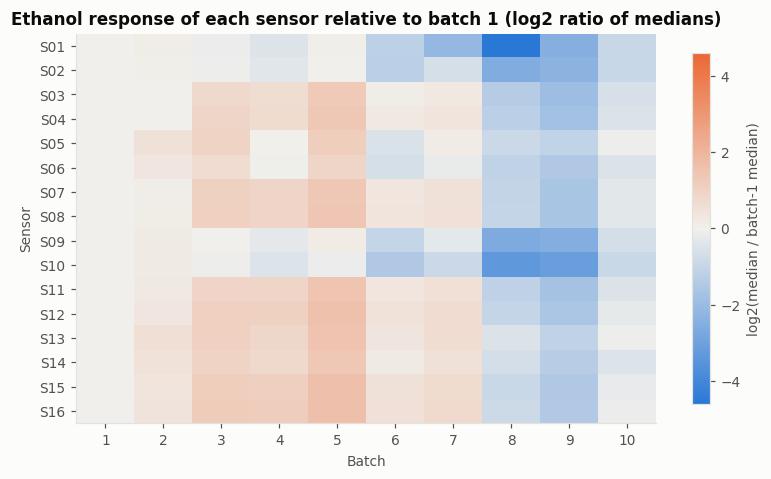

strongest weakening: -4.60 log2 (x0.041) at sensor S01, batch 8 | strongest increase: 1.65 log2 (x3.13)
share of sensor-batch cells that differ from batch 1 by more than 2x (|log2| > 1), batches 2-10: 36%


In [5]:
g = 1
dr_cols = [i * FEATURES_PER_SENSOR for i in range(N_SENSORS)]          # DR feature of each sensor
med = np.array([[np.median(X[(y == g) & (batch == b)][:, c]) for b in range(1, 11)] for c in dr_cols])
ratio = np.log2(np.where(med / med[:, [0]] > 0, med / med[:, [0]], np.nan))
vmax = np.nanmax(np.abs(ratio))
fig, ax = plt.subplots(figsize=(8.5, 4.6))
im = ax.imshow(ratio, cmap=DIV, vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(10)); ax.set_xticklabels(range(1, 11)); ax.set_yticks(range(N_SENSORS)); ax.set_yticklabels([f"S{s+1:02d}" for s in range(N_SENSORS)])
ax.set_xlabel("Batch"); ax.set_ylabel("Sensor"); ax.grid(False)
ax.set_title("Ethanol response of each sensor relative to batch 1 (log2 ratio of medians)")
fig.colorbar(im, ax=ax, label="log2(median / batch-1 median)", shrink=0.9)
fig.savefig(FIG / "03_ethanol_drift_heatmap.png"); plt.show()
print("strongest weakening:", f"{np.nanmin(ratio):.2f} log2 (x{2**np.nanmin(ratio):.3f}) at sensor S{np.unravel_index(np.nanargmin(ratio), ratio.shape)[0]+1:02d}, batch {np.unravel_index(np.nanargmin(ratio), ratio.shape)[1]+1}",
      "| strongest increase:", f"{np.nanmax(ratio):.2f} log2 (x{2**np.nanmax(ratio):.2f})")
print("share of sensor-batch cells that differ from batch 1 by more than 2x (|log2| > 1), batches 2-10: "
      f"{np.nanmean(np.abs(ratio[:, 1:]) > 1):.0%}")

### 3b. Drift seen through PCA

**PCA** (Principal Component Analysis) squeezes 128 numbers into 2 so we can draw them. Points close together are similar.
Here the data is scaled first, then projected. (For this *exploration* we fit PCA on all data; in the modelling steps PCA
is always fitted on training batches only to avoid leakage.)

- **Left:** coloured by batch - if the colours form separate clouds, time matters.
- **Middle:** coloured by gas - gases should separate if the sensors work.
- **Right:** Ethanol only, coloured by batch - same gas, so any separation is pure drift (plus concentration).

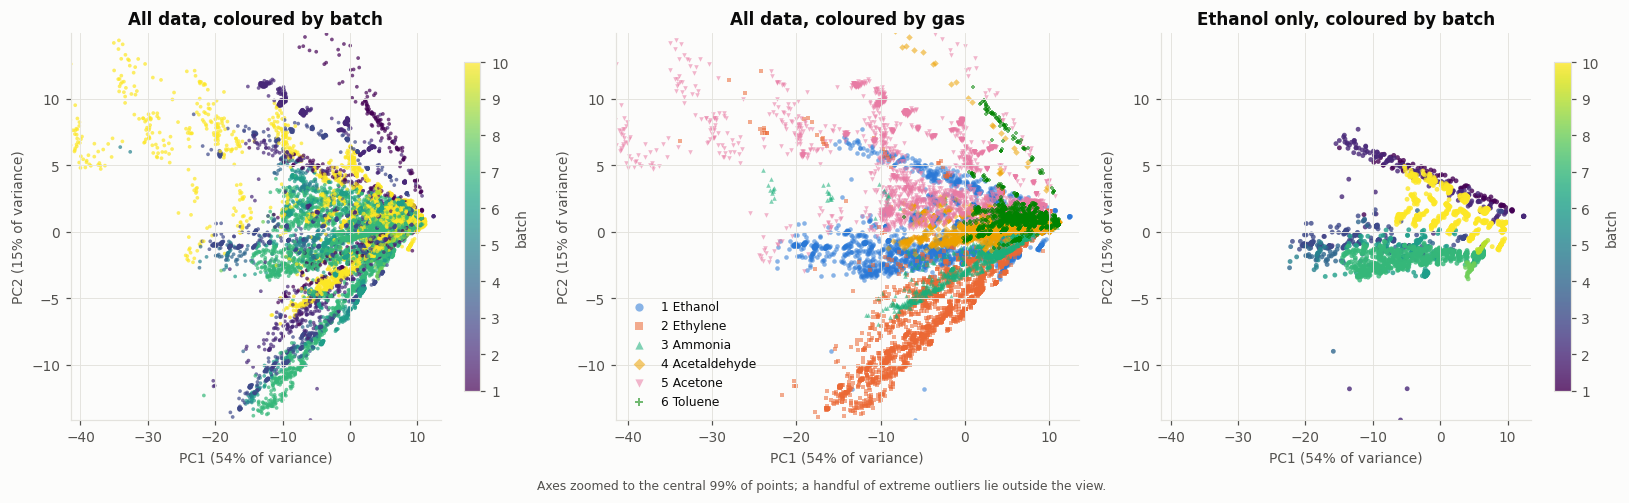

In [6]:
Z = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=0).fit(Z)
P = pca.transform(Z)
ev = pca.explained_variance_ratio_
rng = np.random.RandomState(0); order = rng.permutation(len(y))   # shuffle so no batch hides another

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
ax = axes[0]
sc = ax.scatter(P[order, 0], P[order, 1], c=batch[order], cmap=BATCH_CMAP, s=6, alpha=0.7, linewidths=0)
fig.colorbar(sc, ax=ax, label="batch", ticks=range(1, 11), shrink=0.85)
ax.set_title("All data, coloured by batch")

ax = axes[1]
for gg in range(1, 7):
    m = y == gg
    ax.scatter(P[m, 0], P[m, 1], s=9, alpha=0.55, linewidths=0, color=GAS_COLORS[gg], marker=GAS_MARKERS[gg], label=f"{gg} {GAS_NAMES[gg]}")
ax.legend(markerscale=1.8, frameon=False, fontsize=8, loc="best")
ax.set_title("All data, coloured by gas")

ax = axes[2]
m = y == 1
sc = ax.scatter(P[m, 0], P[m, 1], c=batch[m], cmap=BATCH_CMAP, s=10, alpha=0.8, linewidths=0, vmin=1, vmax=10)
fig.colorbar(sc, ax=ax, label="batch", ticks=range(1, 11), shrink=0.85)
ax.set_title("Ethanol only, coloured by batch")
lo, hi = np.percentile(P, 0.5, axis=0), np.percentile(P, 99.5, axis=0)   # zoom on the central 99% (a few extreme points stretch the axes)
pad = 0.05 * (hi - lo)
for a in axes:
    a.set_xlim(lo[0] - pad[0], hi[0] + pad[0]); a.set_ylim(lo[1] - pad[1], hi[1] + pad[1])
    a.set_xlabel(f"PC1 ({ev[0]:.0%} of variance)"); a.set_ylabel(f"PC2 ({ev[1]:.0%} of variance)")
fig.text(0.5, -0.02, "Axes zoomed to the central 99% of points; a handful of extreme outliers lie outside the view.", ha="center", fontsize=8, color=INK2)
fig.tight_layout(); fig.savefig(FIG / "04_pca_batch_gas.png"); plt.show()

## 4. Feature analysis

**4a. Which sensors behave alike?** Correlation runs from -1 to +1; values near +1 mean two sensors rise and fall together,
so they carry overlapping (redundant) information. We use the steady-state `DR` feature of each sensor.

**4b. Which feature types are redundant?** For each sensor the 8 features are of 3 kinds: steady-state (`DR`, `|DR|`),
rising moving averages (`EMA_inc`), decaying moving averages (`EMA_dec`). The matrix shows the average correlation between
each pair of feature types, computed within a sensor.

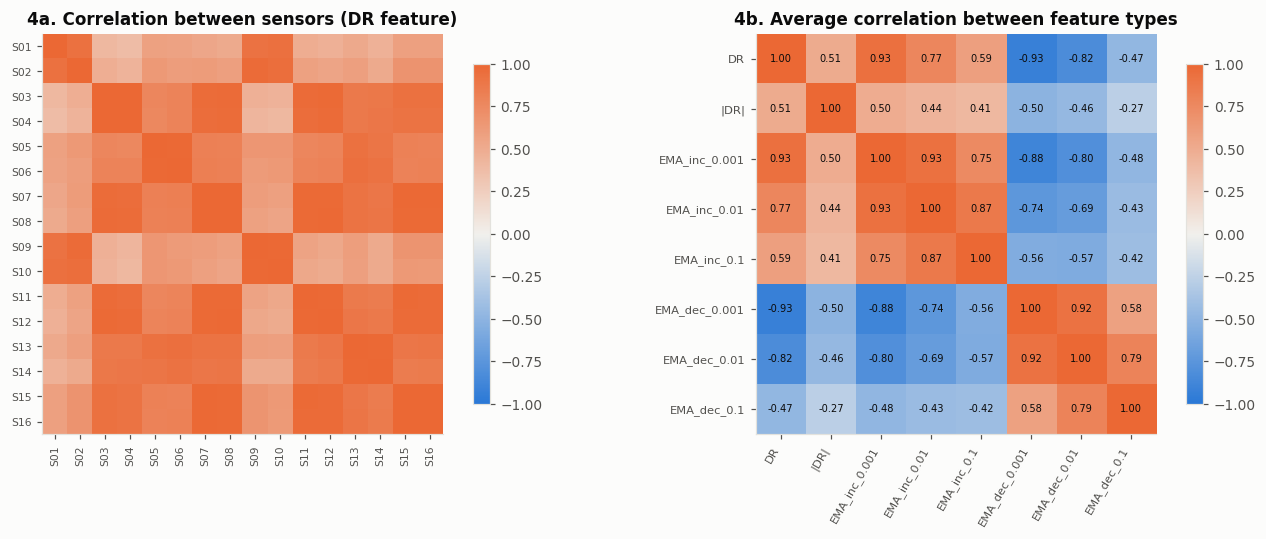

mean |corr| between different sensors (DR): 0.77


In [7]:
dr = X[:, dr_cols]
corr_s = np.corrcoef(dr.T)
# average within-sensor correlation between feature types
blocks = X.reshape(len(y), N_SENSORS, FEATURES_PER_SENSOR)
corr_t = np.mean([np.corrcoef(blocks[:, s, :].T) for s in range(N_SENSORS)], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), gridspec_kw={"width_ratios": [1, 1]})
ax = axes[0]
im = ax.imshow(corr_s, cmap=DIV, vmin=-1, vmax=1); ax.grid(False)
ax.set_xticks(range(N_SENSORS)); ax.set_yticks(range(N_SENSORS))
ax.set_xticklabels([f"S{s+1:02d}" for s in range(N_SENSORS)], rotation=90, fontsize=7); ax.set_yticklabels([f"S{s+1:02d}" for s in range(N_SENSORS)], fontsize=7)
ax.set_title("4a. Correlation between sensors (DR feature)"); fig.colorbar(im, ax=ax, shrink=0.85)
ax = axes[1]
im = ax.imshow(corr_t, cmap=DIV, vmin=-1, vmax=1); ax.grid(False)
ax.set_xticks(range(8)); ax.set_yticks(range(8)); ax.set_xticklabels(FEATURE_TYPES, rotation=60, ha="right", fontsize=7.5); ax.set_yticklabels(FEATURE_TYPES, fontsize=7.5)
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{corr_t[i, j]:.2f}", ha="center", va="center", fontsize=6.5, color=INK)
ax.set_title("4b. Average correlation between feature types"); fig.colorbar(im, ax=ax, shrink=0.85)
fig.tight_layout(); fig.savefig(FIG / "05_feature_correlations.png"); plt.show()
print("mean |corr| between different sensors (DR):", round(float(np.abs(corr_s[np.triu_indices(N_SENSORS, 1)]).mean()), 2))

**4c. Which feature types drift the most?** For Ethanol only, for every feature we measure how far the batch *median* has moved
from the batch-1 median, in units of that feature's robust spread (IQR/1.349 over all Ethanol samples). Then we average over the
16 sensors for each of the 8 feature types. Darker = that feature type moved further from its batch-1 value.
This is a first, *descriptive* look; the proper analysis (permutation importance) comes later in the project.

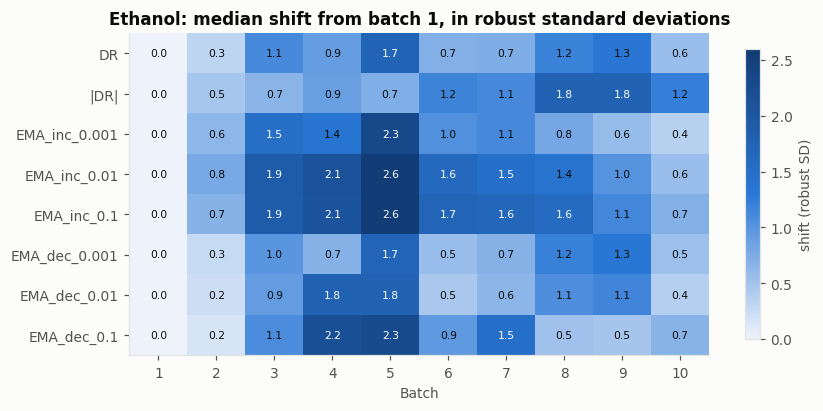

,1,2,3,4,5,6,7,8,9,10,mean (B2-10)
DR,0.0,0.32,1.09,0.91,1.75,0.72,0.73,1.18,1.32,0.55,0.95
|DR|,0.0,0.47,0.67,0.89,0.72,1.17,1.11,1.76,1.76,1.22,1.09
EMA_inc_0.001,0.0,0.63,1.50,1.35,2.30,1.04,1.10,0.80,0.58,0.36,1.08
EMA_inc_0.01,0.0,0.77,1.89,2.10,2.59,1.62,1.48,1.39,1.01,0.55,1.49
EMA_inc_0.1,0.0,0.68,1.86,2.05,2.59,1.73,1.65,1.56,1.13,0.70,1.55
EMA_dec_0.001,0.0,0.26,0.98,0.69,1.70,0.55,0.70,1.20,1.30,0.54,0.88
EMA_dec_0.01,0.0,0.23,0.92,1.79,1.76,0.45,0.65,1.06,1.15,0.38,0.93
EMA_dec_0.1,0.0,0.16,1.08,2.17,2.25,0.94,1.48,0.53,0.48,0.67,1.08


In [8]:
E = X[y == 1]; eb = batch[y == 1]
scale = (np.percentile(E, 75, axis=0) - np.percentile(E, 25, axis=0)) / 1.349
scale = np.where(scale == 0, np.nan, scale)
meds = np.array([np.median(E[eb == b], axis=0) for b in range(1, 11)])          # (10, 128)
shift = np.abs(meds - meds[0]) / scale                                           # (10, 128)
shift_t = shift.reshape(10, N_SENSORS, FEATURES_PER_SENSOR).mean(axis=1).T       # (8 types, 10 batches)
shift_df = pd.DataFrame(shift_t, index=FEATURE_TYPES, columns=range(1, 11)); shift_df.to_csv(RES / "01_feature_type_drift.csv")

fig, ax = plt.subplots(figsize=(8.5, 3.8))
im = ax.imshow(shift_t, cmap=SEQ, aspect="auto"); ax.grid(False)
ax.set_xticks(range(10)); ax.set_xticklabels(range(1, 11)); ax.set_yticks(range(8)); ax.set_yticklabels(FEATURE_TYPES)
for i in range(8):
    for j in range(10):
        ax.text(j, i, f"{shift_t[i, j]:.1f}", ha="center", va="center", fontsize=7, color="white" if shift_t[i, j] > shift_t.max() * 0.55 else INK)
ax.set_xlabel("Batch"); ax.set_title("Ethanol: median shift from batch 1, in robust standard deviations")
fig.colorbar(im, ax=ax, label="shift (robust SD)", shrink=0.9)
fig.savefig(FIG / "06_feature_type_drift.png"); plt.show()
shift_df["mean (B2-10)"] = shift_df[list(range(2, 11))].mean(axis=1)
shift_df.to_csv(RES / "01_feature_type_drift.csv")
display(shift_df.round(2))

## 5. Leakage check: can the features reveal the batch (time)?

If a model can tell **which batch** a sample came from using only the sensor readings, then the readings contain *time information*.
With a random train/test split, test samples then have near-identical "twins" in the training set (same batch, same conditions),
so accuracy looks great but says nothing about the future. This is the concern raised by Dennler et al. (2022).

Test: a Random Forest (default settings) tries to predict the batch ID with 5-fold cross-validation.
**Chance level** is what you would get by always guessing the biggest batch.

> This is *indirect* evidence: this copy of the dataset does not include the raw baseline readings that Dennler et al. analysed.

,accuracy,balanced_accuracy,chance_accuracy
"All gases (13,910 samples)",0.992,0.984,0.260
Ethanol only (same gas),0.985,0.975,0.253


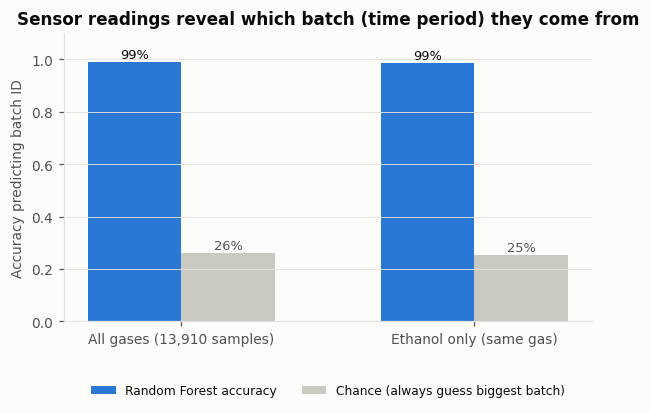

In [9]:
def batch_predictability(Xs, bs, seed=42):
    clf = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
    pred = cross_val_predict(clf, Xs, bs, cv=StratifiedKFold(5, shuffle=True, random_state=seed))
    chance = np.bincount(bs).max() / len(bs)
    return dict(accuracy=accuracy_score(bs, pred), balanced_accuracy=balanced_accuracy_score(bs, pred), chance_accuracy=chance)

rows = {"All gases (13,910 samples)": batch_predictability(X, batch),
        "Ethanol only (same gas)": batch_predictability(X[y == 1], batch[y == 1])}
pred_df = pd.DataFrame(rows).T; pred_df.to_csv(RES / "01_batch_predictability.csv")
display(pred_df.round(3))

fig, ax = plt.subplots(figsize=(6.2, 3.4))
xs = np.arange(len(pred_df)); w = 0.32
ax.bar(xs - w/2, pred_df["accuracy"], w, color="#2a78d6", label="Random Forest accuracy")
ax.bar(xs + w/2, pred_df["chance_accuracy"], w, color="#c9c8c1", label="Chance (always guess biggest batch)")
for i, (a, c_) in enumerate(zip(pred_df["accuracy"], pred_df["chance_accuracy"])):
    ax.text(i - w/2, a + 0.015, f"{a:.0%}", ha="center", fontsize=8.5, color=INK)
    ax.text(i + w/2, c_ + 0.015, f"{c_:.0%}", ha="center", fontsize=8.5, color=INK2)
ax.set_xticks(xs); ax.set_xticklabels(pred_df.index); ax.set_ylim(0, 1.1); ax.set_ylabel("Accuracy predicting batch ID")
ax.set_title("Sensor readings reveal which batch (time period) they come from")
ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2); ax.grid(axis="x", visible=False)
fig.savefig(FIG / "07_batch_predictability.png"); plt.show()

## 6. Key takeaways

1. **Data is clean but badly scaled.** 13,910 samples x 128 features, no missing values, no duplicates, no constant features. Values range from about -23,661 to 670,687, so scaling is mandatory for kNN, SVM, PCA and LDA.
2. **Class balance changes over time.** Toluene (gas 6) has only 5 samples in batch 2 and none in batches 3-5. Batches 4 and 5 are tiny (161 and 197 samples; batch 4 has just 12 Ammonia and 12 Acetone samples). Batch 10 is perfectly balanced (600 per gas). So **macro-F1** will be the main metric, and scores on small batches (4, 5, 8) are less reliable. Training on batches 1-3 sees only 79 Toluene samples.
3. **Drift is visible.** For the same gas (Ethanol), 36% of sensor-batch combinations respond more than 2x differently from batch 1. Sensor S01 in batch 8 responds at only 0.04x of its batch-1 level (about 1/24th), and the strongest increase is 3.1x. It is not a uniform gain change: sensors S01, S02, S09, S10 weaken sharply in batches 8-9, while most others first strengthen (batches 3-5) and then weaken.
4. **PCA shows the same gas in different places at different times.** In the Ethanol-only plot, batches 1-2, batches 3-7 and batch 10 occupy clearly different regions.
5. **Features are highly redundant.** The average absolute correlation between different sensors is 0.77. Within a sensor, `DR` correlates +0.93 with `EMA_inc_0.001` and -0.93 with `EMA_dec_0.001`; `|DR|` is the least redundant feature. This supports using PCA and LDA.
6. **Rising moving-average features drift most (descriptive, Ethanol only).** `EMA_inc_0.01` and `EMA_inc_0.1` move about 1.5 robust standard deviations away from batch 1 on average, versus roughly 0.9-1.1 for the other feature types. This is only a first look; permutation importance comes later.
7. **Leakage warning confirmed (indirect evidence).** A default Random Forest predicts the batch ID from the sensor readings with **99.2%** accuracy (chance 26.0%), and **98.5%** using Ethanol samples alone (chance 25.3%). The features carry a strong time fingerprint, so a random train/test split would put near-identical "twins" in both sets and overstate accuracy. Time-aware splits are therefore essential (Step 2).

**Implications for the next steps:** always scale inside a pipeline fitted on training batches only, evaluate with time-aware splits, report macro-F1 together with accuracy, and treat tiny or class-missing batches with care.